# Energy Bill Analytics

## Objetivo

Analisar o consumo residencial de energia elétrica utilizando as faturas de julho de 2024, 2025 e 2026 para praticar limpeza, análise e visualização de dados com Python e Pandas.

## Importação das bibliotecas

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

## Carregamento dos dados

In [29]:
df = pd.read_excel("energy_bill.xlsx")
df



,ano,mes,competencia,consumo_kwh,dias_faturados,valor_energia,icms,pis,cofins,cosip,valor_total,custo_kwh,consumo_medio_diario_kwh,observacoes
0,2024,Julho,07/2024,135,30,97.09,11.65,0.57,2.62,13.04,110.13,0.815778,4.500,yellow flag
1,2025,Julho,07/2025,292,32,232.14,33.67,0.90,4.09,33.98,276.90,0.948288,9.125,red flag patamar1+ juros multa e correção
2,2026,Julho,07/2026,168,32,149.25,18.76,1.86,8.59,15.30,176.85,1.052679,5.250,yellow flag


In [31]:
df.head()

,ano,mes,competencia,consumo_kwh,dias_faturados,valor_energia,icms,pis,cofins,cosip,valor_total,custo_kwh,consumo_medio_diario_kwh,observacoes
0,2024,Julho,07/2024,135,30,97.09,11.65,0.57,2.62,13.04,110.13,0.815778,4.500,yellow flag
1,2025,Julho,07/2025,292,32,232.14,33.67,0.90,4.09,33.98,276.90,0.948288,9.125,red flag patamar1+ juros multa e correção
2,2026,Julho,07/2026,168,32,149.25,18.76,1.86,8.59,15.30,176.85,1.052679,5.250,yellow flag


## Exploração inicial dos dados

In [33]:
df.shape

(3, 14)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ano                       3 non-null      int64  
 1   mes                       3 non-null      object 
 2   competencia               3 non-null      object 
 3   consumo_kwh               3 non-null      int64  
 4   dias_faturados            3 non-null      int64  
 5   valor_energia             3 non-null      float64
 6   icms                      3 non-null      float64
 7   pis                       3 non-null      float64
 8   cofins                    3 non-null      float64
 9   cosip                     3 non-null      float64
 10  valor_total               3 non-null      float64
 11  custo_kwh                 3 non-null      float64
 12  consumo_medio_diario_kwh  3 non-null      float64
 13  observacoes               3 non-null      object 
dtypes: float64(8),

In [32]:
df.describe()

,ano,consumo_kwh,dias_faturados,valor_energia,icms,pis,cofins,cosip,valor_total,custo_kwh,consumo_medio_diario_kwh
count,3.0,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,2025.0,198.333333,31.333333,159.493333,21.360000,1.110000,5.100000,20.773333,187.960000,0.938915,6.291667
std,1.0,82.778822,1.154701,68.105213,11.237887,0.670149,3.110514,11.492995,83.938265,0.118728,2.482229
min,2024.0,135.000000,30.000000,97.090000,11.650000,0.570000,2.620000,13.040000,110.130000,0.815778,4.500000
25%,2024.5,151.500000,31.000000,123.170000,15.205000,0.735000,3.355000,14.170000,143.490000,0.882033,4.875000
50%,2025.0,168.000000,32.000000,149.250000,18.760000,0.900000,4.090000,15.300000,176.850000,0.948288,5.250000
75%,2025.5,230.000000,32.000000,190.695000,26.215000,1.380000,6.340000,24.640000,226.875000,1.000483,7.187500
max,2026.0,292.000000,32.000000,232.140000,33.670000,1.860000,8.590000,33.980000,276.900000,1.052679,9.125000


## Análise Exploratória



In [35]:
df.columns

Index(['ano', 'mes', 'competencia', 'consumo_kwh', 'dias_faturados',
       'valor_energia', 'icms', 'pis', 'cofins', 'cosip', 'valor_total',
       'custo_kwh', 'consumo_medio_diario_kwh', 'observacoes'],
      dtype='object')

In [36]:
df.isnull().sum()

,0
ano,0
mes,0
competencia,0
consumo_kwh,0
dias_faturados,0
valor_energia,0
icms,0
pis,0
cofins,0
cosip,0


## Análise dos Indicadores

Após verificar a consistência do conjunto de dados, inicia-se a análise dos principais indicadores relacionados ao consumo de energia elétrica e ao valor da fatura ao longo dos anos.

In [37]:
df[['ano','consumo_kwh']]

,ano,consumo_kwh
0,2024,135
1,2025,292
2,2026,168


In [38]:
df[['ano','valor_total']]

,ano,valor_total
0,2024,110.13
1,2025,276.90
2,2026,176.85


In [39]:
df[['ano','custo_kwh']]

,ano,custo_kwh
0,2024,0.815778
1,2025,0.948288
2,2026,1.052679


In [40]:
df[['ano','consumo_medio_diario_kwh']]

,ano,consumo_medio_diario_kwh
0,2024,4.500
1,2025,9.125
2,2026,5.250


In [41]:
df[['ano','observacoes']]

,ano,observacoes
0,2024,yellow flag
1,2025,red flag patamar1+ juros multa e correção
2,2026,yellow flag


In [42]:
#Qual foi o maior consumo
df.loc[df['consumo_kwh'].idxmax(), ['ano', 'consumo_kwh']]

,1
ano,2025
consumo_kwh,292


In [43]:
#Qual foi a menor conta?
df.loc[df['valor_total'].idxmin(), ['ano', 'valor_total']]

,0
ano,2024
valor_total,110.13


In [44]:
#Qual foi o maior custo por kWh?
df.loc[df['custo_kwh'].idxmax(), ['ano', 'custo_kwh']]


,2
ano,2026
custo_kwh,1.052679


In [45]:
#Qual foi o maior consumo médio diário?
df.loc[df['consumo_medio_diario_kwh'].idxmax(), ['ano', 'consumo_medio_diario_kwh']]

,1
ano,2025
consumo_medio_diario_kwh,9.125


## Visualizações

Nesta etapa são apresentadas visualizações que facilitam a comparação dos principais indicadores entre os anos analisados.

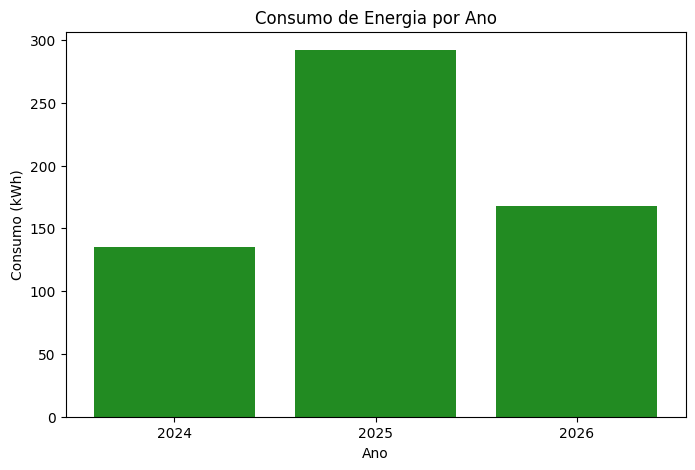

In [46]:
# Gráfico 1 - Consumo por Ano

plt.figure(figsize=(8,5))

plt.bar(
    df['ano'],
    df['consumo_kwh'],
    color='forestgreen'
)

plt.xticks(df['ano'])
plt.title('Consumo de Energia por Ano')
plt.xlabel('Ano')
plt.ylabel('Consumo (kWh)')

plt.show()

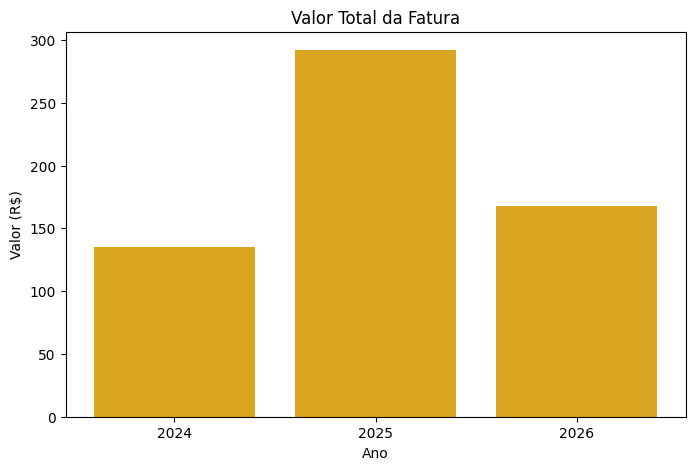

In [47]:
#Gráfico 2 — Valor da conta

plt.figure(figsize=(8,5))

plt.bar(df['ano'], df['consumo_kwh'], color='goldenrod')

plt.xticks(df['ano'])

plt.title('Valor Total da Fatura')
plt.xlabel('Ano')
plt.ylabel('Valor (R$)')

plt.show()

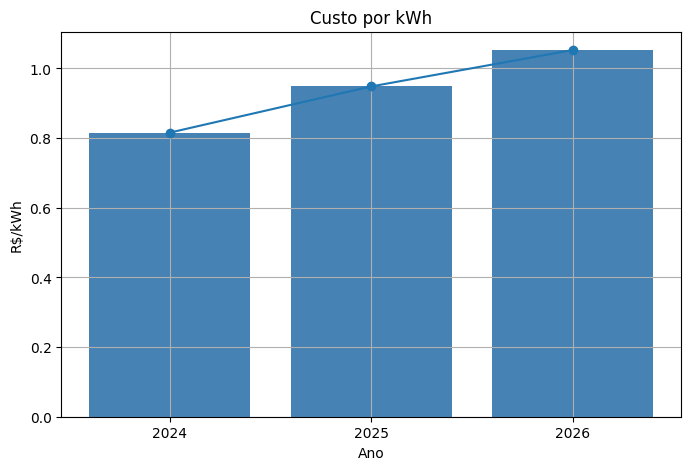

In [48]:
#Gráfico 3 — Custo por kWh

plt.figure(figsize=(8,5))

plt.plot(df['ano'], df['custo_kwh'], marker='o')

plt.bar(df['ano'], df['custo_kwh'], color='steelblue')

plt.xticks(df['ano'])

plt.title('Custo por kWh')
plt.xlabel('Ano')
plt.ylabel('R$/kWh')

plt.grid()

plt.show()


# Conclusões

A análise das faturas de energia elétrica permitiu transformar um documento do cotidiano em um conjunto de dados estruturado, possibilitando a aplicação de técnicas de análise exploratória, cálculo de indicadores e visualização de informações com Python, Pandas e Matplotlib.

Os resultados mostram que o maior consumo de energia ocorreu em julho de 2025 (292 kWh), refletindo também na maior fatura do período (R$ 276,90). Além do aumento no consumo, a presença da Bandeira Vermelha Patamar 1 e de encargos financeiros registrados na fatura contribuíram para elevar ainda mais o valor final pago naquele mês.

Em 2026, embora o consumo tenha retornado a um patamar significativamente menor (168 kWh), o custo por kWh foi o mais elevado entre os anos analisados. Esse resultado indica que o valor final da conta depende não apenas da quantidade de energia consumida, mas também das condições tarifárias vigentes e de outros componentes que compõem a cobrança.

Mesmo utilizando um conjunto reduzido de dados, o projeto demonstra como documentos aparentemente simples podem ser transformados em informações estruturadas capazes de apoiar análises e subsidiar decisões.

# Insights

- O consumo de energia é um dos principais fatores que influenciam o valor da fatura, mas não é o único.

- Alterações nas bandeiras tarifárias podem aumentar significativamente o custo da energia consumida, tornando períodos de tarifas mais elevadas especialmente sensíveis ao consumo.

- Monitorar simultaneamente consumo, custo por kWh e bandeira tarifária permite compreender melhor as variações da conta de energia ao longo do tempo.

- Em períodos com bandeiras tarifárias mais caras, pequenas reduções no consumo tendem a produzir maior impacto financeiro na fatura.

- A transformação da fatura em um dataset evidencia como documentos operacionais podem ser convertidos em informações analíticas para apoiar decisões baseadas em dados.

Dados relevantes nem sempre estão em grandes bases de dados. Muitas vezes, eles estão presentes em documentos do cotidiano que, quando estruturados e analisados, revelam padrões, apoiam decisões e ampliam a compreensão sobre a realidade observada.